FileNotFoundError: No such file or no access: 'BraTS-GLI-02536-100/BraTS-GLI-02536-100-t1c.nii'

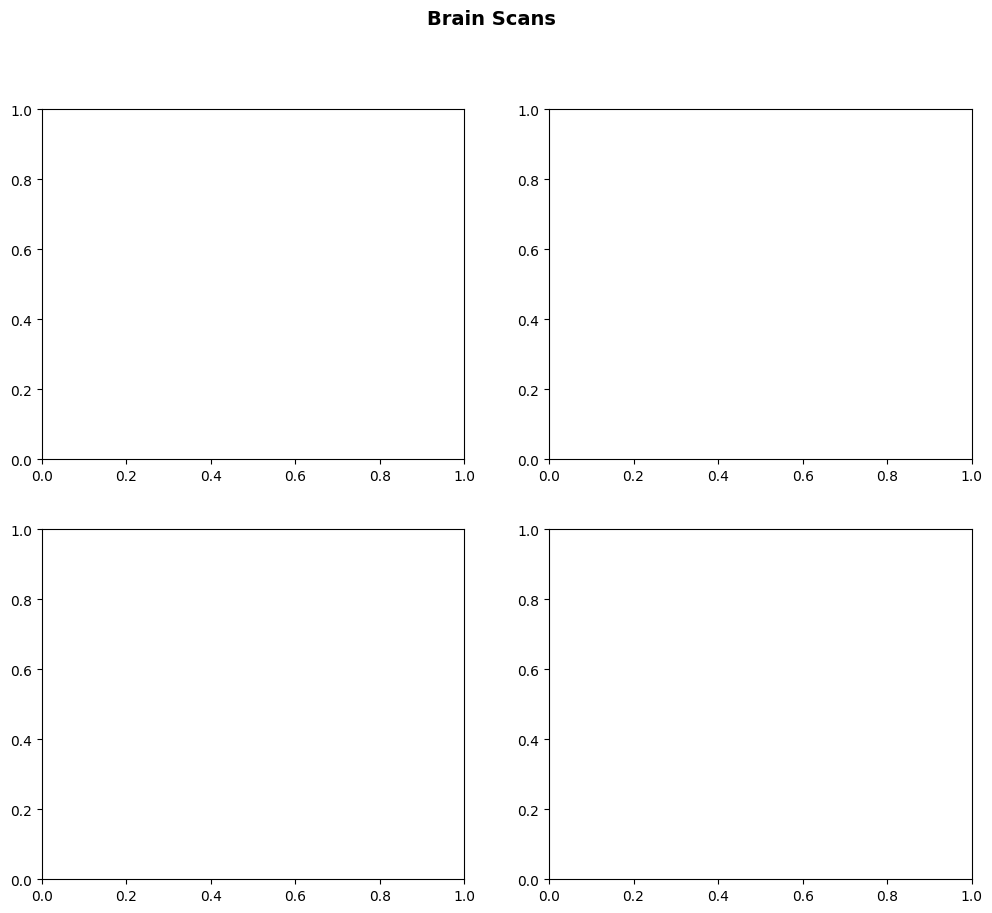

In [1]:
#Visualizing Inputs
#Subplot of t1c,t1n, t2f and t2w for a single z-slice of a brain scan

#for loading file into an array
import nibabel as nib
#for plotting
import matplotlib.pyplot as plt

#file names
t1c = "BraTS-GLI-02536-100/BraTS-GLI-02536-100-t1c.nii"
t1n = "BraTS-GLI-02536-100/BraTS-GLI-02536-100-t1n.nii"
t2f = "BraTS-GLI-02536-100/BraTS-GLI-02536-100-t2f.nii"
t2w = "BraTS-GLI-02536-100/BraTS-GLI-02536-100-t2w.nii"
seg = "BraTS-GLI-02536-100/BraTS-GLI-02536-100-seg.nii"

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
files = [t1c, t1n, t2f, t2w]
titles = ['t1c', 't1n', 't2f', 't2w']
axes_flat = axes.flatten()

fig.suptitle("Brain Scans",fontweight="bold",fontsize=14)

z_slice = None

for idx, (file_path, title) in enumerate(zip(files, titles)):
    img = nib.load(file_path)
    data = img.get_fdata()
    
    #Select the z-slice as the middle of the brain 
    if z_slice is None:
        z_slice = data.shape[2] // 2
    
    #Extract z-slice from 3d image
    slice_data = data[:, :, z_slice]
    
    #plotting image
    axes_flat[idx].imshow(slice_data.T, cmap='gray', origin='lower')
    axes_flat[idx].set_title(title, fontsize=12, fontweight='bold')
    axes_flat[idx].axis('off')

plt.subplots_adjust(wspace=-0.45, hspace=0.1,top=0.935)
plt.show()


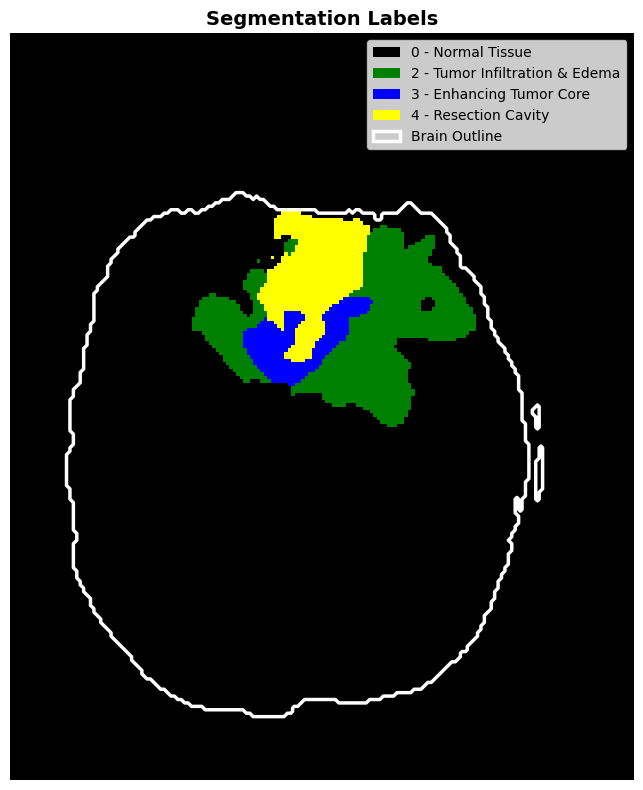

Label 0: 36722 voxels
Label 2: 1736 voxels
Label 3: 405 voxels
Label 4: 813 voxels


In [ ]:
# Plot segmentation labels for same z-slice as inputs
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors


#load segmentation image and convert to array
seg_img = nib.load(seg)
seg_data = seg_img.get_fdata()

#loading input image to get outline of brain
t2w_img = nib.load(t2w)
t2w_data = t2w_img.get_fdata()

#Same z-slice as the input images
z_slice = seg_data.shape[2] // 2


fig, ax = plt.subplots(figsize=(8, 8))

#Color map for each label
colors_list = ['black', 'red', 'green', 'blue', 'yellow']

#Taking z-slice of 3d segmentation map
seg_slice = seg_data[:, :, z_slice]

# Get unique values that are present in the slice
unique_vals = np.unique(seg_slice)
unique_vals = np.sort(unique_vals).astype(int)

#Color map for only values that exist in the slice
colors_for_unique = [colors_list[v] for v in unique_vals]
cmap_unique = mcolors.ListedColormap(colors_for_unique)
#plotting segmentation labels
norm = mcolors.BoundaryNorm(boundaries=np.concatenate([[unique_vals[0]-0.5], unique_vals + 0.5]), ncolors=len(unique_vals))
im = ax.imshow(seg_slice.T, cmap=cmap_unique, norm=norm, origin='lower')

#Getting the outline of the brain 

#creating boolean array of brain scan where data is higher than threshold
t2w_slice = t2w_data[:, :, z_slice]
brain_thresh = np.percentile(t2w_slice, 10)
brain_mask_slice = (t2w_slice > brain_thresh).astype(float)
#using contour function to make a contour from the boolean array
ax.contour(brain_mask_slice.T, levels=[0.5], colors='white', linewidths=2.5, origin='lower')

ax.set_title('Segmentation Labels', fontsize=14, fontweight='bold')
ax.axis('off')

#Label Names for Segmentation Map
label_names = {
    0: 'Normal Tissue',
    1: 'Necrotic Tumor Core',
    2: 'Tumor Infiltration & Edema',
    3: 'Enhancing Tumor Core',
    4: 'Resection Cavity'
}
#add segmentation to legend
patches = [mpatches.Patch(facecolor=colors_list[v], label=f'{v} - {label_names[v]}') for v in unique_vals]
# Add brain outline to legend
patches.append(mpatches.Patch(facecolor='none', edgecolor='white', linewidth=2.5, label='Brain Outline'))
ax.legend(handles=patches, loc='upper right')

plt.tight_layout()
plt.show()

# Print count of each label in the z-slice
unique, counts = np.unique(seg_slice, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Label {int(label)}: {count} voxels")